In [1]:
from scipy.optimize import minimize
from scipy.optimize import direct, Bounds
from smooth_POD_ROM.post_processing import richardson_lucy
from smooth_POD_ROM.pre_processing import smoothen_rowwise
from smooth_POD_ROM.initial_conditions import rectangular_pulse, rect_pulse_sin, saw_tooth, triangle, small_saw_tooth, small_r_pulse
#from smooth_POD_ROM.reduced_order_model import optimize_hyperparameters, target_function
from smooth_POD_ROM.reduced_order_model import make_data_rw, train_ROM_rw, L2_error_rw, get_data_rw
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

In [2]:
# tmeplate: X_randMU

In [3]:
import matplotlib.pyplot as plt
import matplotlib as mpl
page_width_pt = 455.24
pt2in = 0.01389 
pt2cm = 0.0352777778
cm2in = 1/2.54
page_width_cm = 13.70499
# TODO: work with textwidth
plot_width_in = page_width_pt*pt2in/2
page_width_in = page_width_cm*cm2in
print(plot_width_in/cm2in)

fs = 10
fs_lbl = 6
plt.rcParams["figure.figsize"] = (plot_width_in, plot_width_in/1.61803398875)
plt.rcParams["figure.autolayout"] = True
plt.rcParams['font.size'] = fs
plt.rcParams['axes.titlesize'] = fs
plt.rcParams['axes.labelsize'] = fs
plt.rcParams['xtick.labelsize'] = fs
plt.rcParams['ytick.labelsize'] = fs
plt.rcParams['legend.labelspacing'] = 0.0
plt.rcParams['legend.fontsize'] = fs_lbl
plt.rcParams['legend.handlelength'] = 2.0

plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
mpl.rc('text', usetex=True)
mpl.rc('font', family='serif', size=fs, serif='Computer Modern Roman')
pth = "../Plots/"

markevery = 40

8.030570172000001


In [4]:
def small_saw_tooth(x, mu):
    return saw_tooth(x, mu, w=1/45)

In [5]:
n_x = 5000
x = np.linspace(0, 1, n_x, endpoint=False)
case = {
    "n_x": n_x,
    "shape": x.shape,
    "x": x,
    "dx": x[1] - x[0],

    "n_train": 10,
    "n_test": 25,
    "g": small_saw_tooth, #saw_tooth, #rectangular_pulse,
    "truncate": 12,
    "sigma": 0.08,

    "c": 1,
    "monitor_progress_postprocessing": False,
    "num_iter": 200,
    "monitor_convergence": False,
}

In [6]:
def get_predictions(
    sROM,
    mu_,
    sigma,
    c,
    num_iter,
    shape,
    x,
    monitor_progress_postprocessing=False,
    monitor_convergence=False,
    sigmaD="calc_based_on_distance",
    **kwargs
):
    X_test_sROM = sROM.predict(mu_).snapshots_matrix
    mu_train = sROM.database.parameters_matrix
    data = X_test_sROM
    return X_test_sROM


def get_improvement(X_test, X_test_ROM, X_test_sROM):
    e_ROM = L2_error_rw(X_test_ROM, X_test)
    mean_ROM = np.mean(e_ROM)
    e_sROM = L2_error_rw(X_test_sROM, X_test)
    mean_sROM = np.mean(e_sROM)
    improvement = 100 * mean_sROM/ mean_ROM - 100
    return mean_ROM, mean_sROM, improvement


def target_function(case):
    if ("n_train" in case.keys()) and ("mu_train" in case.keys()):
        raise ValueError("training data is ambiguous, 'n_train' and 'mu_train' are given.")
    if ("n_test" in case.keys()) and ("mu_test" in case.keys()):
        raise ValueError("testing data is ambiguous, 'n_test' and 'mu_test' are given.")

    if "n_train" in case.keys():
        mu_train, X_train, X_train_s = make_data_rw([0], [1], n_samples=case["n_train"], **case)
    elif "mu_train" in case.keys():
        mu_train = case["mu_train"]
        X_train, X_train_s = get_data_rw(mu_train, **case)

    if "n_test" in case.keys():
        mu_test, X_test, X_test_s = make_data_rw(
            mu_train[1], mu_train[2], n_samples=case["n_test"], **case
        )
    elif "mu_test" in case.keys():
        mu_test = case["mu_test"]
        X_test, X_test_s = get_data_rw(mu_test, **case)

    my_ROM = train_ROM_rw(mu_train, X_train)
    my_sROM = train_ROM_rw(mu_train, X_train_s)

    X_test_ROM = my_ROM.predict(mu_test).snapshots_matrix
    X_test_sROM = get_predictions(my_sROM, mu_test, **case)
    mean_ROM, mean_sROM, improvement = get_improvement(
        X_test, X_test_ROM, X_test_sROM)
    return mean_sROM # improvement


def optimize_hyperparameters(case):
    rank = case["rank"]
    #sigma_opt = 1 / (rank * 2)
    sigma_opt = .1 / (rank)
    

    def target(params):
        case["sigma"] = params[0]
        res = target_function(case)
        print("target", case["sigma"], res)
        return res

    # x0 = np.array([sigma_opt])
    # res = minimize(
    #     target,
    #     x0,
    #     method="SLSQP",
    #     bounds=[(0.0, 5 * sigma_opt)],
    #     options={"disp": True, "eps": np.array([sigma_opt/10]), "maxiter": 100, "ftol": 0.000001},
    # )
    print("max:", 2 * sigma_opt)
    bounds = Bounds([0.00001], [2 * sigma_opt])
    res = direct(target, bounds, eps=1e-3, len_tol=0.0025)  # max side length_abs=[0.006, 0.25]
    print("optim. res", case["rank"], sigma_opt, 5 * sigma_opt, res["x"])
    return res["x"]

(0.1, 0.2)

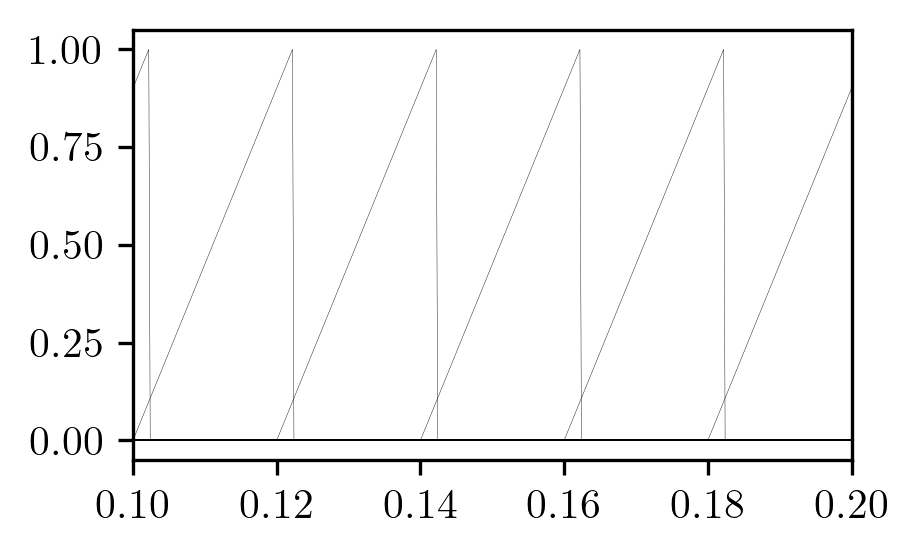

In [7]:
rank = 50
case["rank"] = n_train = rank

mu_train = np.linspace([0], [1], n_train, endpoint=False)
#case["mu_train"] = mu_train

X_train, X_train_s= get_data_rw(mu_train, **case)
for i in range(len(X_train)):
    plt.plot(x, X_train[i], "k-", lw=.1)
plt.xlim(.1, .2)

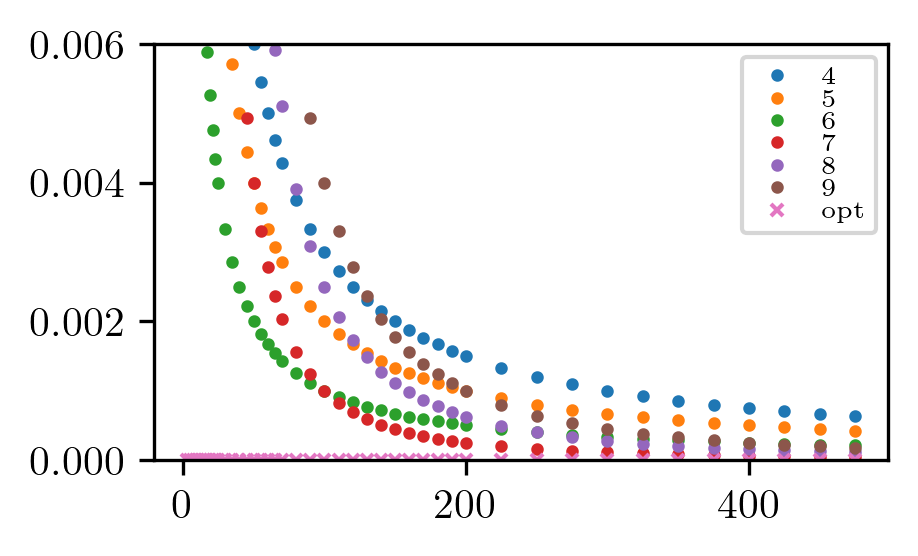

3
max: 0.06666666666666667
target 0.03333833333333333 0.07993413765691307
target 0.055557222222222216 0.08108714851919725
target 0.011119444444444446 0.08352025236894577
target 0.04074462962962963 0.08023593645258083
target 0.025932037037037038 0.07997182002151848
target 0.06296351851851852 0.08149848051372514
target 0.048150925925925916 0.08065308196293279
target 0.035807098765432095 0.08001170713203805
target 0.030869567901234567 0.07989238654720776
target 0.018525740740740742 0.08081088479979065
target 0.00371314814814815 0.09151786065230044
target 0.028400802469135802 0.07989948061447527
target 0.02346327160493827 0.08012974914197697
target 0.043213395061728395 0.0803687872843979
target 0.03827586419753087 0.08011491930176354
target 0.031692489711934155 0.07990158404879433
target 0.03004664609053498 0.07988858852970047
target 0.05061969135802468 0.08079863497999704
target 0.04568216049382716 0.08050896217523826
target 0.02922372427983539 0.07989075147535844
target 0.027577880658436

In [8]:
g = case["g"]

shape = case["shape"]
num_iter1 = 100
num_iter2 = 250

#def estimate_dN():

# num_iter = 200
#NN = np.array([*np.arange(4, 30, 2), *np.arange(30, 150, 10)])
NN = np.array([*np.arange(3, 25, 2), *np.arange(25, 75, 5), *np.arange(80, 200, 10), *np.arange(200, 500, 25)])
dN_ROM = np.zeros(len(NN))
dN_sig = np.zeros((len(NN), 10))

sig = np.zeros((len(NN), 10))
sig[:, 1] = .05/NN**.5
sig[:, 2] = .01/NN**.5
sig[:, 3] = .001/NN**.5
#sig[:, 3] = .4 / (NN)
sig[:, 4] = .3 / (NN)
sig[:, 5] = .2 / (NN)
sig[:, 6] = .1 / (NN)
sig[:, 7] = 10 / (NN**2)
sig[:, 8] = 25 / (NN**2)
sig[:, 9] = 40 / (NN**2)


for i in range(4, 10):
    plt.plo2(NN, sig[:, i], "o", ms=2, label=str(i))
plt.plot(NN, sig[:, 0], "x", ms=3, label="opt")
plt.legend()
plt.ylim(0, 0.006)
plt.show()

for i, rank in enumerate(NN):
    print(rank)
    case["num_iter"] = num_iter1
    case["rank"] = n_train = rank
    
    mu_min, mu_max = np.array([0]), np.array([1])
    # mu_train = np.atleast_2d(np.random.rand(n_train,)[:, None] * (mu_max - mu_min) + mu_min)
    # mu_min, mu_max = np.min(mu_train), np.max(mu_train)
    # mu_test = np.atleast_2d(np.random.rand(n_test,)[:, None] * (mu_max - mu_min) + mu_min)

    mu_train = np.linspace(mu_min, mu_max, n_train, endpoint=False)
    mu_min, mu_max = mu_train[1], mu_train[2]
    mu_test = np.linspace(mu_min, mu_max, case["n_test"], endpoint=False)

    
    #case["mu_train"], case["mu_test"] = mu_train, mu_test
    parameters = optimize_hyperparameters(case)
    sig[i, 0] = parameters[0]

    #for sigS, dN in zip([sig_opt, sig_1, sig_2, sig_3, sig_4], [dN_sig_opt, dN_sig_1, dN_sig_2, dN_sig_3, dN_sig_4]):
    for j in range(10):
        sigS = sig[:, j]
        #dN = dN_sig[:, j]
        #print(sig[i, j])
        case["sigma"] = sig[i, j]
        X_train, X_train_s= get_data_rw(mu_train, **case)
        X_test, X_test_s  = get_data_rw(mu_test, **case)
        
        my_ROM = train_ROM_rw(mu_train, X_train)
        my_sROM = train_ROM_rw(mu_train, X_train_s)
    
        X_test_ROM = my_ROM.predict(mu_test).snapshots_matrix
        X_test_sROM = get_predictions(my_sROM, mu_test, **case)
        mean_ROM, mean_sROM, improvement = get_improvement(X_test, X_test_ROM, X_test_sROM)
    
        dN_sig[i, j] = mean_sROM
        
    dN_ROM[i] = mean_ROM


log log plot
plot sig S opt


In [16]:
lbls = ["optimized", ".05/N**.5", ".01/N**.5", ".001/N**.5", "0.3/N", "0.2/N",  "0.1/N", "10/(N**2)", "25/(N**2)", "40/(N**2)"]

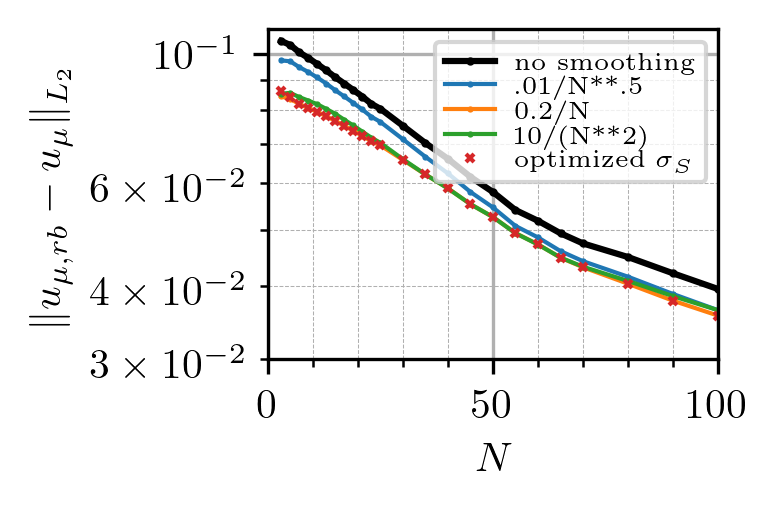

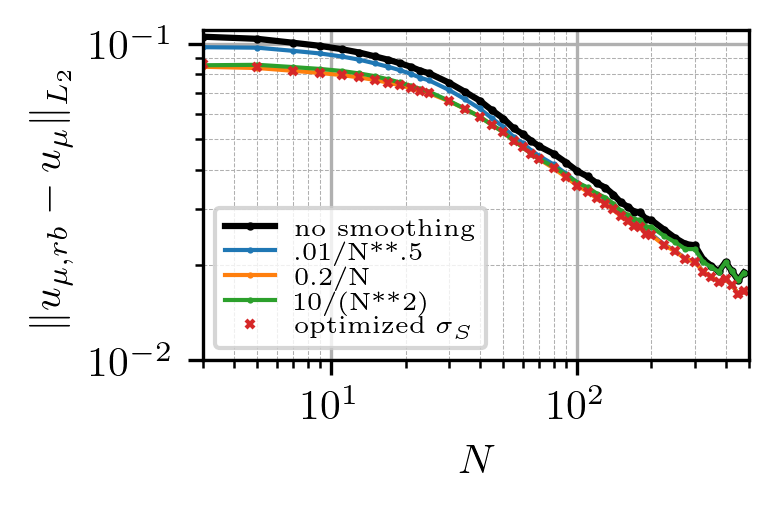

In [37]:
fig, ax = plt.subplots(figsize=(page_width_in / 2, page_width_in / 3))
#plt.plot(NN, esROM, "C1--", ms=2, label="$u_{rb,S}$")
plt.plot(NN, dN_ROM, "k.-", ms=2, label=r"no smoothing")
for i in [2, 5, 7]: #range(4, 10):
    plt.plot(NN, dN_sig[:, i], ls="-", marker=".", lw=1, ms=1, label=lbls[i])# r"$u_{\mu,Srb}$"
plt.plot(NN, dN_sig[:, 0], ls="None", marker="x", lw=1, ms=2, label=r"optimized $\sigma_S$")# r"$u_{\mu,Srb}$"
# plt.plot(NN, dN_sig_1, "C2.-", ms=2, label=r"$u_{\mu,Srb}$")
# plt.plot(NN, dN_sig_2, "C3.-", ms=2, label=r"$u_{\mu,Srb}$")
# plt.plot(NN, dN_sig_3, "C4.-", ms=2, label=r"$u_{\mu,Srb}$")
# plt.plot(NN, dN_sig_4, "C5.-", ms=2, label=r"$u_{\mu,Srb}$")
plt.legend()
plt.ylabel(r"$\|u_{\mu,rb}-u_{\mu}\|_{L_2}$")
plt.xlabel(r"$N$")
# plt.ylim(0, 0.4)
plt.legend()
ax.set_xticks(np.linspace(0, 500, 51, endpoint=True), minor=True)
ax.set_yticks(np.linspace(0, 0.4, 19, endpoint=True), minor=True)
plt.grid(True, which="minor", linestyle="--", lw=0.25)
plt.grid(True, which="major", linestyle="-")
#ax.set_xscale("log")
ax.set_yscale("log")
plt.xlim(0, 100)
plt.ylim(3e-2, 0.11)
plt.show()

fig, ax = plt.subplots(figsize=(page_width_in / 2, page_width_in / 3))
plt.plot(NN, dN_ROM, "k.-", ms=2, label="no smoothing")
for i in [2, 5, 7]: #range(4, 10):
    plt.plot(NN, dN_sig[:, i], ls="-", marker=".", lw=1, ms=1, label=lbls[i])# r"$u_{\mu,Srb}$"
plt.plot(NN, dN_sig[:, 0], ls="None", marker="x", lw=1, ms=2, label=r"optimized $\sigma_S$")# r"$u_{\mu,Srb}$"
plt.legend()
plt.ylabel(r"$\|u_{\mu,rb}-u_{\mu}\|_{L_2}$")
plt.xlabel(r"$N$")
# plt.ylim(0, 0.4)
plt.legend()
ax.set_xticks(np.linspace(0, 500, 51, endpoint=True), minor=True)
ax.set_yticks(np.linspace(0, 0.4, 19, endpoint=True), minor=True)
plt.grid(True, which="minor", linestyle="--", lw=0.25)
plt.grid(True, which="major", linestyle="-")
ax.set_xscale("log")
ax.set_yscale("log")
plt.xlim(3, 500)
plt.ylim(1e-2, 0.11)
plt.show()

Text(0, 0.5, '$\\sigma_S$')

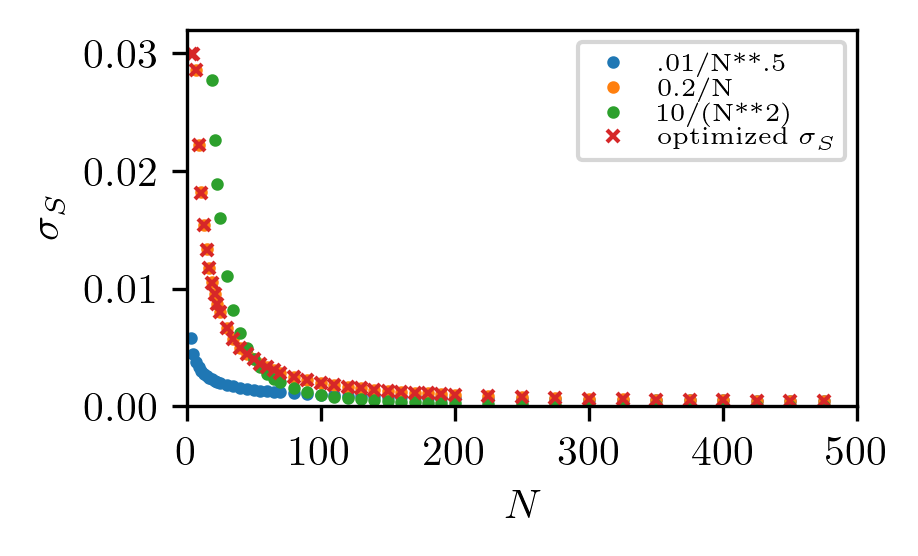

In [28]:
for i in [2, 5, 7]: #range(4, 10):
    plt.plot(NN, sig[:, i], "o", ms=2, label=lbls[i])
plt.plot(NN, sig[:, 0], "x", ms=3, label=r"optimized $\sigma_S$")
plt.legend()
plt.xlim(0, 500)
plt.ylim(0, 0.032)
plt.xlabel("$N$")
plt.ylabel(r"$\sigma_S$")